# Lab 3 — Confusion Matrix & Classification Metrics

**Day 03 · Classification & Model Interpretation · Cisco AI/ML Training**

---

## Goals

1. Build and read a **confusion matrix** (rows = true, cols = predicted).
2. Label **TP, FP, TN, FN** for loan default prediction.
3. Compute **accuracy, precision, recall, F1**.
4. Explore how changing the **decision threshold** shifts precision vs recall.

> **Quick check:** CM `[[63,40],[42,55]]` · accuracy ≈ **0.59** · F1 ≈ **0.57**




## Confusion matrix layout (binary classification)

**Positive class = default (1)**

```
                 Predicted
                 0      1
Actual  0       TN     FP
        1       FN     TP
```

| Cell | Meaning | Business impact |
|------|---------|-----------------|
| **TP** | Correctly flagged default | Catch risky loan |
| **TN** | Correctly cleared safe loan | Approve good borrower |
| **FP** | False alarm | Unnecessary review |
| **FN** | Missed default | **Costly** — loan goes bad |

---

## 1. Train model (same setup as Lab 2)

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

GH_ROOT = Path.cwd().resolve()
if GH_ROOT.name == "notebooks":
    GH_ROOT = GH_ROOT.parents[2]
elif (GH_ROOT.parent / "notebooks").is_dir() and (GH_ROOT.parents[1] / "requirements-student.txt").is_file():
    GH_ROOT = GH_ROOT.parents[1]
else:
    for parent in [GH_ROOT, *GH_ROOT.parents]:
        if (parent / "requirements-student.txt").is_file():
            GH_ROOT = parent
            break

LENDING_CLUB_CSV = GH_ROOT / "data" / "lending-club" / "lending_club_sample.csv"
DEFAULT_STATUSES = {"Charged Off", "Late (31-120 days)"}
NUMERIC_FEATURES = ["loan_amnt", "int_rate", "annual_inc", "dti", "installment"]
CATEGORICAL_FEATURES = ["grade", "term"]

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

df = pd.read_csv(LENDING_CLUB_CSV)
df["default"] = df["loan_status"].isin(DEFAULT_STATUSES).astype(int)

X, y = df[NUMERIC_FEATURES], df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(f"test size: {len(y_test)}")


test size: 200


---

## 2. Confusion matrix

In [2]:
cm = confusion_matrix(y_test, y_pred)
print("Lab 3 — Confusion matrix")
print("rows=true, cols=pred:")
print(cm)

tn, fp, fn, tp = cm.ravel()
print(f"\nTN={tn}, FP={fp}, FN={fn}, TP={tp}")


Lab 3 — Confusion matrix
rows=true, cols=pred:
[[63 40]
 [42 55]]

TN=63, FP=40, FN=42, TP=55


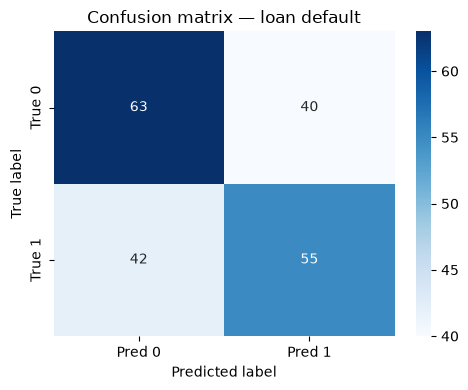

In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", ax=ax,
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["True 0", "True 1"],
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion matrix — loan default")
plt.tight_layout()
plt.show()


### 2b. Label each cell in plain language

In [4]:
print(f"TN={tn}: safe loans correctly approved")
print(f"FP={fp}: good borrowers flagged as default")
print(f"FN={fn}: defaults we missed")
print(f"TP={tp}: defaults correctly caught")


TN=63: safe loans correctly approved
FP=40: good borrowers flagged as default
FN=42: defaults we missed
TP=55: defaults correctly caught


---

## 3. Classification metrics

| Metric | Formula (default=positive) | Question answered |
|--------|---------------------------|-------------------|
| **Accuracy** | (TP+TN) / total | Overall correct? |
| **Precision** | TP / (TP+FP) | Of predicted defaults, how many real? |
| **Recall** | TP / (TP+FN) | Of actual defaults, how many caught? |
| **F1** | Harmonic mean of P & R | Balance precision and recall |

In [5]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

metrics_df = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "F1"],
    "value": [accuracy, precision, recall, f1],
})
display(metrics_df.round(4))

manual_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
print(f"manual precision: {manual_precision:.4f}")


,metric,value
0,accuracy,0.5900
1,precision,0.5789
2,recall,0.5670
3,F1,0.5729


manual precision: 0.5789


### 3b. Manual accuracy check

In [6]:
manual_acc = (tn + tp) / (tn + fp + fn + tp)
print(f"manual accuracy: {manual_acc:.4f}")
print(f"sklearn accuracy: {accuracy:.4f}")


manual accuracy: 0.5900
sklearn accuracy: 0.5900


---

## 4. `classification_report`

In [7]:
print(classification_report(y_test, y_pred, zero_division=0))


              precision    recall  f1-score   support

           0       0.60      0.61      0.61       103
           1       0.58      0.57      0.57        97

    accuracy                           0.59       200
   macro avg       0.59      0.59      0.59       200
weighted avg       0.59      0.59      0.59       200



**Support** = number of true instances per class in the test set.

### 4b. Per-class precision and recall

In [8]:
from sklearn.metrics import precision_recall_fscore_support

p, r, f, s = precision_recall_fscore_support(y_test, y_pred, zero_division=0)
for label, pi, ri, fi, si in zip([0, 1], p, r, f, s):
    print(f"class {label}: precision={pi:.3f}, recall={ri:.3f}, f1={fi:.3f}, support={si}")


class 0: precision=0.600, recall=0.612, f1=0.606, support=103
class 1: precision=0.579, recall=0.567, f1=0.573, support=97


---

## 5. Threshold experiment

Default threshold = **0.5**. Lower threshold → more predicted defaults → **higher recall**, often **lower precision**.

In [9]:
def metrics_at_threshold(threshold):
    pred_t = (y_proba >= threshold).astype(int)
    return {
        "threshold": threshold,
        "precision": precision_score(y_test, pred_t, zero_division=0),
        "recall": recall_score(y_test, pred_t, zero_division=0),
        "f1": f1_score(y_test, pred_t, zero_division=0),
    }

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
thresh_df = pd.DataFrame([metrics_at_threshold(t) for t in thresholds])
display(thresh_df.round(4))


,threshold,precision,recall,f1
0,0.3,0.5054,0.9588,0.6619
1,0.4,0.5507,0.7835,0.6468
2,0.5,0.5789,0.5670,0.5729
3,0.6,0.6078,0.3196,0.4189
4,0.7,0.6667,0.0825,0.1468


In [10]:
pred_04 = (y_proba >= 0.4).astype(int)
print("At threshold 0.4:")
print(f"  precision: {precision_score(y_test, pred_04, zero_division=0):.4f}")
print(f"  recall:    {recall_score(y_test, pred_04, zero_division=0):.4f}")
print(f"  F1:        {f1_score(y_test, pred_04, zero_division=0):.4f}")


At threshold 0.4:
  precision: 0.5507
  recall:    0.7835
  F1:        0.6468


**Credit risk framing:** Lower threshold catches more defaults (recall↑) but flags more good loans (precision↓).

### 5b. Plot precision/recall vs threshold

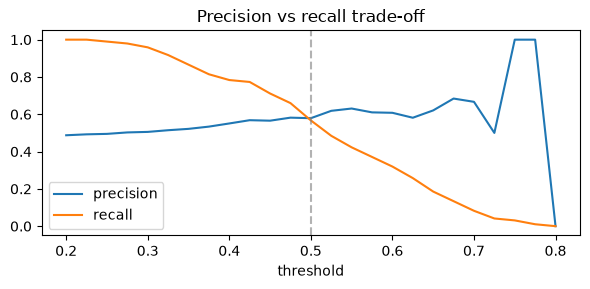

In [11]:
thresh_grid = np.linspace(0.2, 0.8, 25)
prec_list, rec_list = [], []
for t in thresh_grid:
    pred_t = (y_proba >= t).astype(int)
    prec_list.append(precision_score(y_test, pred_t, zero_division=0))
    rec_list.append(recall_score(y_test, pred_t, zero_division=0))

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(thresh_grid, prec_list, label="precision")
ax.plot(thresh_grid, rec_list, label="recall")
ax.axvline(0.5, color="gray", linestyle="--", alpha=0.6)
ax.set_xlabel("threshold")
ax.legend()
ax.set_title("Precision vs recall trade-off")
plt.tight_layout()
plt.show()


---

## 6. Business cost framing

In [12]:
# Hypothetical: FN costs 5x more than FP in review hours
cost_fn, cost_fp = 5.0, 1.0
business_cost = fn * cost_fn + fp * cost_fp
print(f"FN={fn} × {cost_fn} + FP={fp} × {cost_fp} = {business_cost:.0f} cost units")
print("Threshold tuning should reflect real FN vs FP costs.")


FN=42 × 5.0 + FP=40 × 1.0 = 250 cost units
Threshold tuning should reflect real FN vs FP costs.


### 6b. Confusion matrix at threshold 0.3

In [13]:
pred_03 = (y_proba >= 0.3).astype(int)
cm_03 = confusion_matrix(y_test, pred_03)
print("CM at 0.3:")
print(cm_03)


CM at 0.3:
[[12 91]
 [ 4 93]]


### 6c. Confusion matrix at threshold 0.7

In [14]:
pred_07 = (y_proba >= 0.7).astype(int)
cm_07 = confusion_matrix(y_test, pred_07)
print("CM at 0.7:")
print(cm_07)


CM at 0.7:
[[99  4]
 [89  8]]


### 6d. F1 by threshold (bar chart)

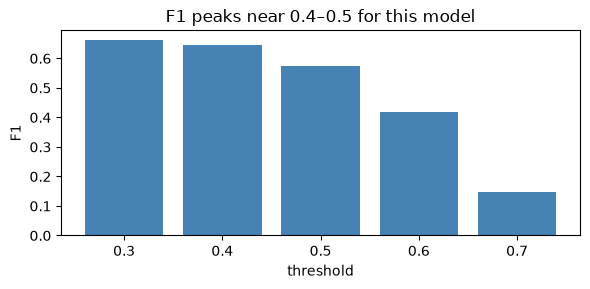

In [15]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(thresh_df["threshold"].astype(str), thresh_df["f1"], color="steelblue")
ax.set_xlabel("threshold")
ax.set_ylabel("F1")
ax.set_title("F1 peaks near 0.4–0.5 for this model")
plt.tight_layout()
plt.show()


### 6e. Misclassified examples — false positives

In [16]:
fp_mask = (y_pred == 1) & (y_test.values == 0)
fp_rows = X_test[fp_mask].head(3)
print(f"false positives: {fp_mask.sum()}")
display(fp_rows)


false positives: 40


,loan_amnt,int_rate,annual_inc,dti,installment
860,28934,17.56,27298,29.30,368.74
389,7505,17.55,69960,19.59,797.05
742,24980,12.71,135431,26.39,193.96


### 6f. Misclassified examples — false negatives

In [17]:
fn_mask = (y_pred == 0) & (y_test.values == 1)
fn_rows = X_test[fn_mask].head(3)
print(f"false negatives: {fn_mask.sum()}")
display(fn_rows)


false negatives: 42


,loan_amnt,int_rate,annual_inc,dti,installment
409,29165,14.84,68264,22.04,659.94
768,11714,7.28,157612,23.92,732.75
352,17451,16.76,140262,8.50,775.56


### 6g. Specificity (true negative rate)

In [18]:
specificity = tn / (tn + fp)
print(f"specificity (TNR): {specificity:.4f}")
print(f"recall (TPR):      {recall:.4f}")


specificity (TNR): 0.6117
recall (TPR):      0.5670


### 6h. Balanced accuracy

In [19]:
balanced_acc = (recall + specificity) / 2
print(f"balanced accuracy: {balanced_acc:.4f}")


balanced accuracy: 0.5893


### 6i. Day 6 contrast — why accuracy fails on imbalance

In [20]:
print("This lab: ~50% defaults → accuracy ≈ 59% is informative.")
print("Day 6 fraud: ~1% fraud → 99% accuracy possible by predicting all legit.")


This lab: ~50% defaults → accuracy ≈ 59% is informative.
Day 6 fraud: ~1% fraud → 99% accuracy possible by predicting all legit.


### 6j. Normalize confusion matrix (rates)

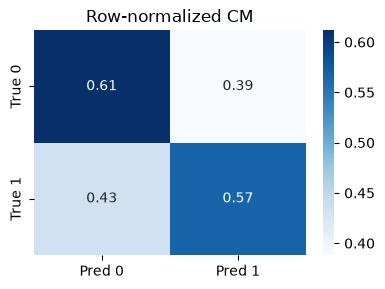

In [21]:
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", ax=ax,
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
ax.set_title("Row-normalized CM")
plt.tight_layout()
plt.show()


### 6k. Predicted positive rate

In [22]:
pred_pos_rate = y_pred.mean()
actual_pos_rate = y_test.mean()
print(f"predicted default rate: {pred_pos_rate:.3f}")
print(f"actual default rate:    {actual_pos_rate:.3f}")


predicted default rate: 0.475
actual default rate:    0.485


### 6l. Matthews correlation coefficient

In [23]:
from sklearn.metrics import matthews_corrcoef
mcc = matthews_corrcoef(y_test, y_pred)
print(f"MCC: {mcc:.4f}")


MCC: 0.1788


### 6m. Harmonic mean manual F1 check

In [24]:
manual_f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
print(f"manual F1: {manual_f1:.4f}, sklearn F1: {f1:.4f}")


manual F1: 0.5729, sklearn F1: 0.5729


### 6n. Score behind misclassified FN

In [25]:
if fn_mask.any():
    fn_scores = y_proba[fn_mask]
    print(f"FN probability scores: min={fn_scores.min():.3f}, max={fn_scores.max():.3f}")


FN probability scores: min=0.244, max=0.497


---

## 7. Try it yourself

At threshold **0.6**, compute precision and recall manually from a new confusion matrix.

In [26]:
# Your code here


In [27]:
pred_06 = (y_proba >= 0.6).astype(int)
cm_06 = confusion_matrix(y_test, pred_06)
tn6, fp6, fn6, tp6 = cm_06.ravel()
print(cm_06)
print(f"precision: {tp6/(tp6+fp6):.4f}, recall: {tp6/(tp6+fn6):.4f}")


[[83 20]
 [66 31]]
precision: 0.6078, recall: 0.3196


---

## 8. Checkpoint summary

In [28]:
assert cm.shape == (2, 2)
assert tn > 0 and fp > 0 and fn > 0 and tp > 0
assert abs(accuracy - 0.59) < 0.02
assert abs(f1 - 0.5729) < 0.02

print("Numbers match — you're good.")
print(f"accuracy: {accuracy:.4f}, F1: {f1:.4f}")



Numbers match — you're good.
accuracy: 0.5900, F1: 0.5729


---

## Reflection questions

1. Which error is worse for a lender — FP or FN? Why?
2. Why is accuracy alone insufficient on Day 6 fraud data (99:1 imbalance)?
3. What metric does Lab 4 (ROC/AUC) add that threshold-based metrics miss?
4. At threshold 0.4 vs 0.5, which metric improved more — precision or recall?
